<a href="https://colab.research.google.com/github/TanuSree02/Deep-learning/blob/main/GRU_Forward_%2B_Backpropagation_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch: 100 Loss: 1.2163601062771345
Epoch: 200 Loss: 0.10592430601876801
Epoch: 300 Loss: 0.04804034170195284
Epoch: 400 Loss: 0.031054427625450513
Epoch: 500 Loss: 0.022975779858043624
Epoch: 600 Loss: 0.018250958878806442
Epoch: 700 Loss: 0.015147869180850839
Epoch: 800 Loss: 0.012952360458207777
Epoch: 900 Loss: 0.011316216030503017
Epoch: 1000 Loss: 0.010049325879248942
Final loss: 0.010049325879248942


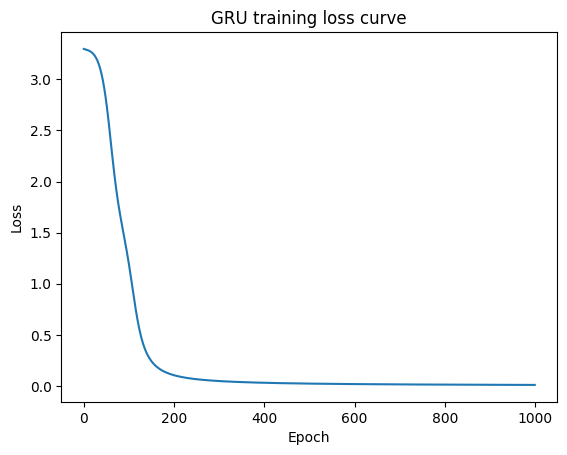

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)


def cross_entropy(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred + 1e-12))


input_size = 3
hidden_size = 2
output_size = 3


def init_gate():
    return np.random.randn(hidden_size, input_size + hidden_size) * 0.1


Wz = init_gate()
Wr = init_gate()
Wh = init_gate()

bz = np.zeros((hidden_size, 1))
br = np.zeros((hidden_size, 1))
bh = np.zeros((hidden_size, 1))

Why = np.random.randn(output_size, hidden_size) * 0.1
by = np.zeros((output_size, 1))


x1 = np.array([[1], [0], [0]])
x2 = np.array([[0], [1], [0]])
x3 = np.array([[0], [0], [1]])

inputs = [x1, x2, x3]


t1 = np.array([[0], [1], [0]])
t2 = np.array([[0], [0], [1]])
t3 = np.array([[1], [0], [0]])

targets = [t1, t2, t3]


learning_rate = 0.1
epochs = 1000

loss_history = []


for epoch in range(epochs):

    h = np.zeros((hidden_size, 1))

    hs = [h]
    zs = []
    rs = []
    h_tildes = []
    ps = []

    loss = 0


    for t in range(3):

        z_input = np.vstack((h, inputs[t]))

        z = sigmoid(Wz @ z_input + bz)

        r = sigmoid(Wr @ z_input + br)

        r_hidden = r * h

        h_input = np.vstack((r_hidden, inputs[t]))

        h_tilde = np.tanh(Wh @ h_input + bh)

        h = (1 - z) * h + z * h_tilde

        y = Why @ h + by

        p = softmax(y)

        loss += cross_entropy(targets[t], p)

        hs.append(h)
        zs.append(z)
        rs.append(r)
        h_tildes.append(h_tilde)
        ps.append(p)

    loss_history.append(loss)


    dWz = np.zeros_like(Wz)
    dWr = np.zeros_like(Wr)
    dWh = np.zeros_like(Wh)
    dWhy = np.zeros_like(Why)

    dbz = np.zeros_like(bz)
    dbr = np.zeros_like(br)
    dbh = np.zeros_like(bh)
    dby = np.zeros_like(by)

    dh_next = np.zeros((hidden_size, 1))


    for t in reversed(range(3)):

        dy = ps[t] - targets[t]

        dWhy += dy @ hs[t+1].T
        dby += dy

        dh = Why.T @ dy + dh_next

        z = zs[t]
        r = rs[t]
        h_prev = hs[t]
        h_tilde = h_tildes[t]

        dh_tilde = dh * z
        dh_prev = dh * (1 - z)

        dh_tilde_raw = dh_tilde * (1 - h_tilde ** 2)

        h_input = np.vstack((r * h_prev, inputs[t]))

        dWh += dh_tilde_raw @ h_input.T
        dbh += dh_tilde_raw

        dr = (Wh.T @ dh_tilde_raw)[:hidden_size] * h_prev

        dr_raw = dr * r * (1 - r)

        z_input = np.vstack((h_prev, inputs[t]))

        dWr += dr_raw @ z_input.T
        dbr += dr_raw

        dz = dh * (h_tilde - h_prev)

        dz_raw = dz * z * (1 - z)

        dWz += dz_raw @ z_input.T
        dbz += dz_raw

        dh_next = dh_prev


    Wz -= learning_rate * dWz
    Wr -= learning_rate * dWr
    Wh -= learning_rate * dWh
    Why -= learning_rate * dWhy

    bz -= learning_rate * dbz
    br -= learning_rate * dbr
    bh -= learning_rate * dbh
    by -= learning_rate * dby


    if (epoch + 1) % 100 == 0:
        print("Epoch:", epoch + 1, "Loss:", loss)


print("Final loss:", loss)

plt.plot(loss_history)
plt.title("GRU training loss curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()